In [27]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_json

from mastercard import dist_visualisation, dist_categorical_visualisation



In [2]:
PROCESSED_DATA = Path("../data/processed")

In [3]:
# RAW_DATA

In [4]:
df = pd.read_parquet(PROCESSED_DATA / 'transactions.parquet')

In [5]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [6]:
print('Initial shape', df.shape)

Initial shape (500000, 14)


In [7]:
# List features
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [8]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [9]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [10]:
df.sample(n=10)

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
127908,TX127908,2022-12-07 14:30:00,U15971,M0750,50.30,in-store,EUR,Web,"{'lat': 65.788324, 'long': 30.438821}",credit_card,1,686,0,0
92540,TX092540,2023-02-03 17:34:00,U16893,M0229,102.59,in-store,EUR,iOS,"{'lat': 53.421487, 'long': 31.644588}",debit_card,1,350,1,0
471011,TX471011,2023-05-10 15:34:00,U07254,M0666,9.63,online,EUR,Web,"{'lat': 39.821139, 'long': 31.031789}",mobile_payment,1,696,1,0
440278,TX440278,2022-11-04 23:52:00,U06601,M0027,25.90,in-store,EUR,iOS,"{'lat': 47.14695, 'long': -6.572205}",credit_card,1,973,1,0
154072,TX154072,2023-10-26 10:49:00,U12789,M0920,67.54,online,EUR,iOS,"{'lat': 69.249476, 'long': -0.30563599999999996}",debit_card,1,1047,0,0
77344,TX077344,2022-06-09 00:57:00,U08271,M0535,12.47,in-store,EUR,Android,"{'lat': 35.494874, 'long': 12.058666}",bank_transfer,1,926,1,0
355624,TX355624,2023-12-03 14:05:00,U19258,M0606,118.27,mobile,EUR,Android,"{'lat': 47.236666, 'long': 3.528848}",credit_card,1,173,0,0
139539,TX139539,2022-07-26 12:58:00,U05039,M0813,33.57,mobile,EUR,Android,"{'lat': 53.709651, 'long': 31.075785}",debit_card,1,436,0,0
213839,TX213839,2023-01-18 12:49:00,U03342,M0640,4.49,mobile,EUR,iOS,"{'lat': 41.692516, 'long': -1.470916}",mobile_payment,1,817,0,0
338349,TX338349,2023-03-11 07:53:00,U01119,M0493,15.83,mobile,EUR,iOS,"{'lat': 66.243335, 'long': 30.345938}",credit_card,1,780,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   transaction_id          500000 non-null  object        
 1   timestamp               500000 non-null  datetime64[ns]
 2   user_id                 500000 non-null  object        
 3   merchant_id             500000 non-null  object        
 4   amount                  500000 non-null  float64       
 5   channel                 500000 non-null  object        
 6   currency                500000 non-null  object        
 7   device                  500000 non-null  object        
 8   location                500000 non-null  object        
 9   payment_method          500000 non-null  object        
 10  is_international        500000 non-null  int64         
 11  session_length_seconds  500000 non-null  int64         
 12  is_first_time_merchant  500000

## Descriptive statistics

- univariate analysis
- bivariate analysis
- multivariate analysis

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,500000,2022-12-31 16:45:04.497720576,2022-01-01 00:06:00,2022-07-01 11:03:45,2022-12-31 20:08:30,2023-07-02 08:45:15,2023-12-31 23:57:00,NaN
amount,500000.0,49.915662,0.0,14.37,34.56,69.1725,714.86,49.990657
is_international,500000.0,0.928662,0.0,1.0,1.0,1.0,1.0,0.257389
session_length_seconds,500000.0,614.987182,30.0,323.0,614.0,907.0,1200.0,338.091496
is_first_time_merchant,500000.0,0.501248,0.0,0.0,1.0,1.0,1.0,0.499999
is_fraud,500000.0,0.084822,0.0,0.0,0.0,0.0,1.0,0.278617


### Target variable

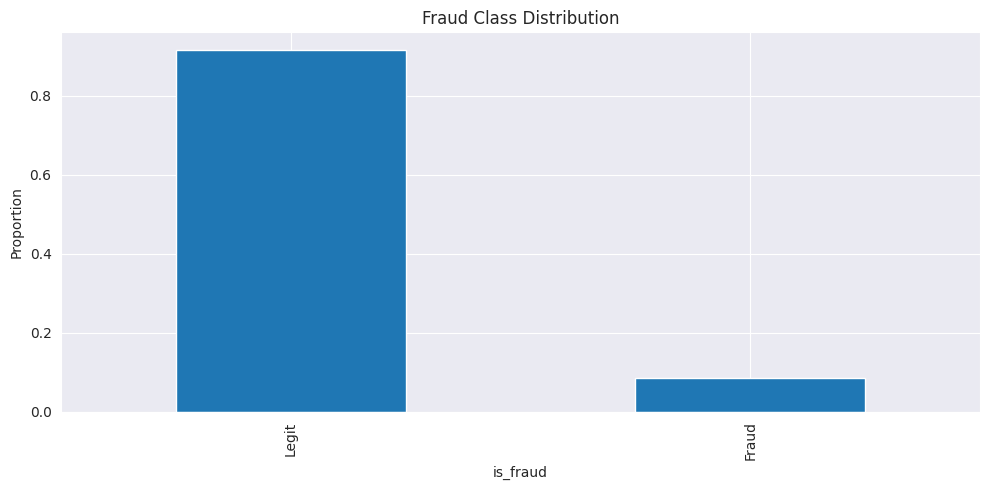

In [13]:
fraud_counts = df['is_fraud'].value_counts(normalize=True)

fix, ax = plt.subplots(figsize=(10, 5))

fraud_counts.plot(kind='bar', ax=ax)
ax.set_title('Fraud Class Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

##### Summary: Class distribution is highly imbalanced

- accuracy - will be misleading
- use metrics like F1-score, Recall, ROC-AUC
- consider resampling (undersample, oversample)
- use algorithms with bulit-in the support imbalanced data (e.g. XGBoost)

### Numerical features

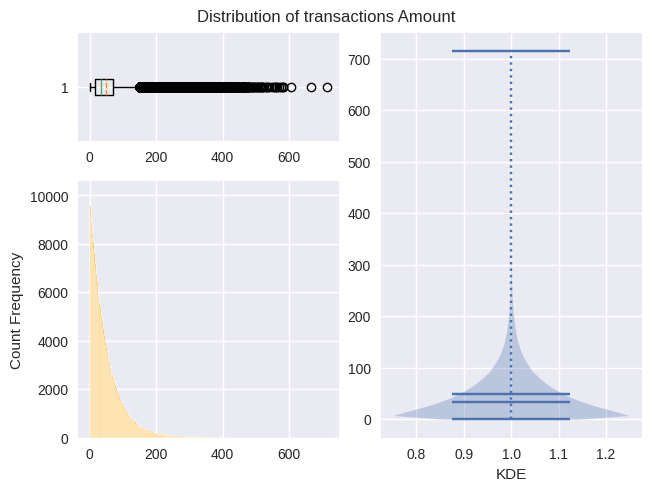

In [14]:
dist_visualisation(df['amount'], title='Distribution of transactions Amount')

In [15]:
df.loc[df['amount'] < 1, 'amount'].count()

np.int64(9986)

In [16]:
df.loc[df['amount'] == 0, 'amount'].count()

np.int64(43)

In [17]:
df['amount'].describe()

count    500000.000000
mean         49.915662
std          49.990657
min           0.000000
25%          14.370000
50%          34.560000
75%          69.172500
max         714.860000
Name: amount, dtype: float64

#### Summary: amount is strongly right-skewed with a long tail, this suggest the presence of outliers

- recommendation: apply log transformation (e.g.log1p) for algorithms sensitive to distribution shape

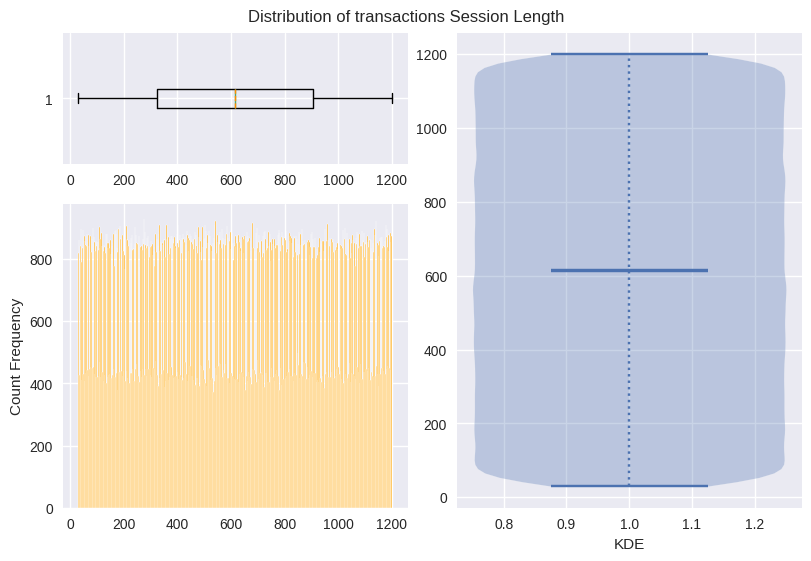

In [18]:
dist_visualisation(df['session_length_seconds'], title='Distribution of transactions Session Length')

#### Summary: session_length_seconds is uniform distributed, which is unusual in real behavioral data

- indicates synthetic generation or flattening
- low predictive power unless frauds are focused in specific ranges (to be checked later)

## Categorical features

In [19]:
df.dtypes

transaction_id                    object
timestamp                 datetime64[ns]
user_id                           object
merchant_id                       object
amount                           float64
channel                           object
currency                          object
device                            object
location                          object
payment_method                    object
is_international                   int64
session_length_seconds             int64
is_first_time_merchant             int64
is_fraud                           int64
dtype: object

In [20]:
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'merchant_id', 'amount',
       'channel', 'currency', 'device', 'location', 'payment_method',
       'is_international', 'session_length_seconds', 'is_first_time_merchant',
       'is_fraud'],
      dtype='object')

In [21]:
categorical_cols = ['channel', 'currency', 'device', 'payment_method', 'is_international', 'is_first_time_merchant' ]

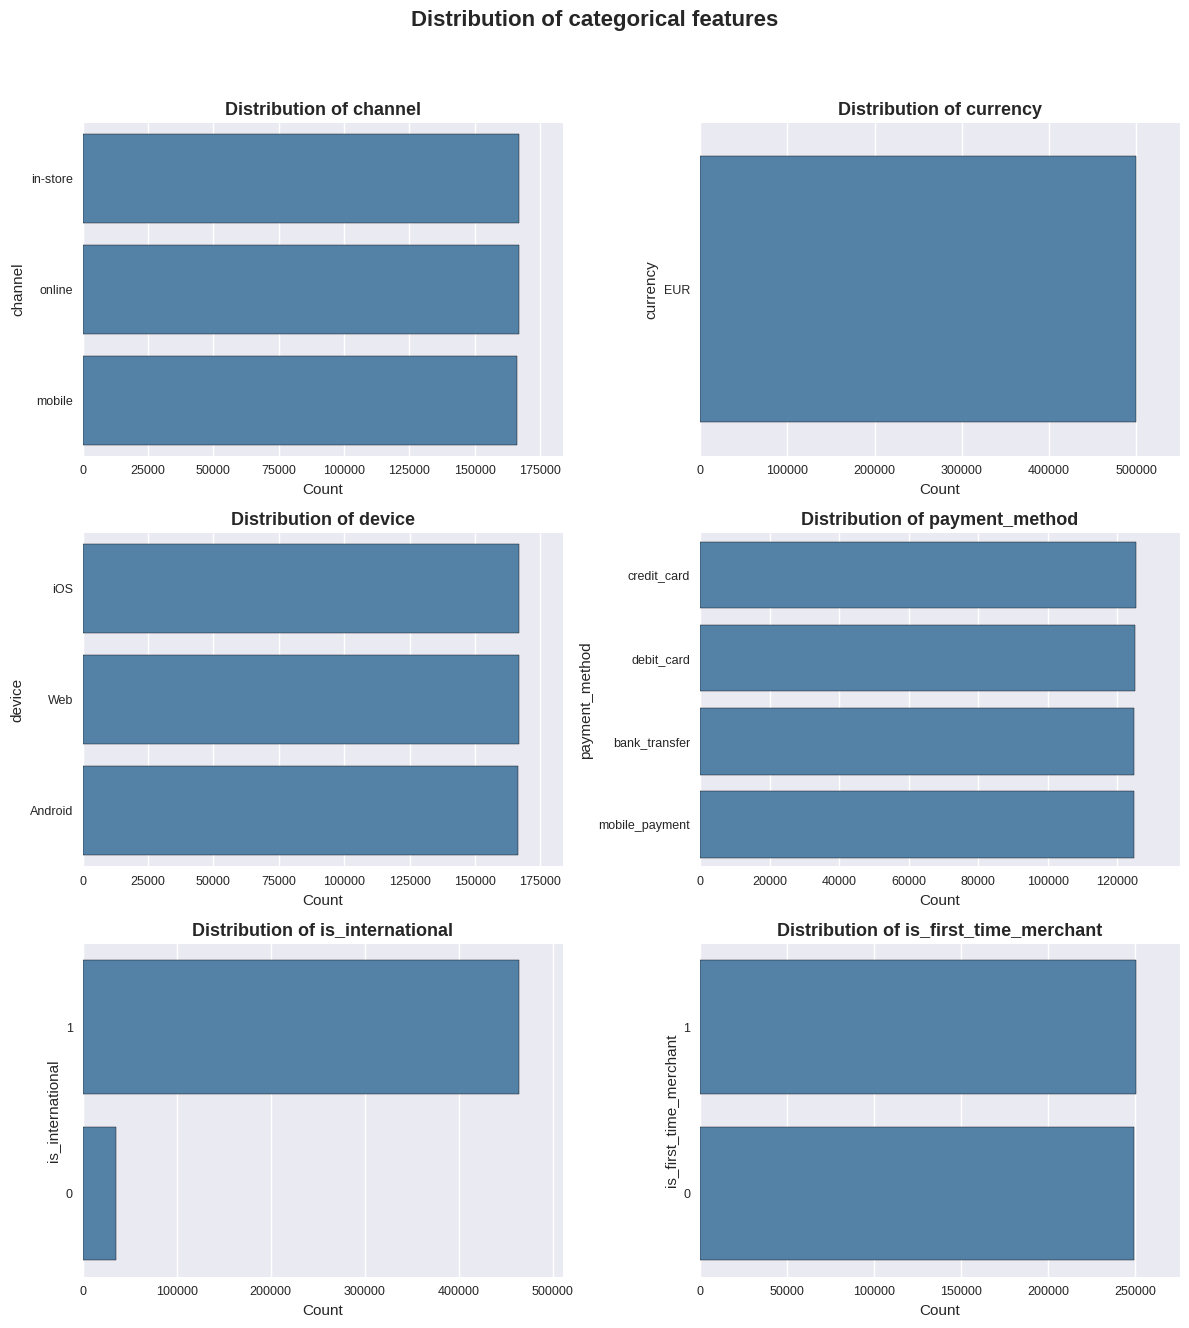

In [22]:
fig, ax = dist_categorical_visualisation(df, categorical_cols, title='Distribution of categorical features')

In [23]:
df['channel'].value_counts()

channel
in-store    167027
online      166847
mobile      166126
Name: count, dtype: int64

#### Summary:
- channel, device, payment_method show almost perfectly balanced category distribution
    - unusual in real-word data and indicates synthetic balancing or controlled generation
- currency has only one value, making it non-informative
    - recommended : drop this feature

## Multivariate analysis

#### Amount vs is_fraud

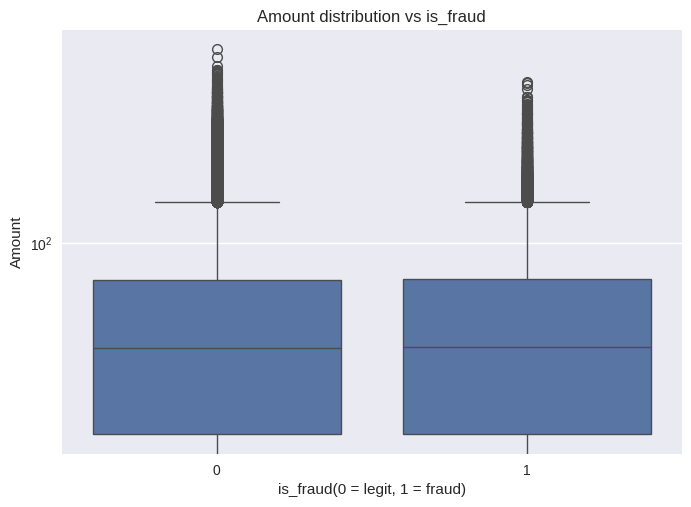

In [24]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='amount', data=df, ax=ax)
ax.set_title('Amount distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Amount')
ax.set_yscale('log')

#### Summary:
- amount is not a discriminative feature by itself for froud detection
- distribution are very similar
- may still be useful when combined with other features

#### Session Length Seconds vs is_fraud

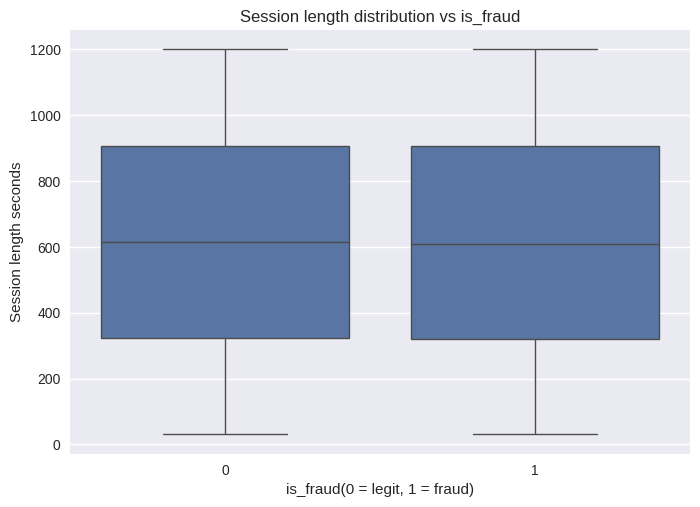

In [30]:
fig, ax = plt.subplots()

sns.boxplot(x='is_fraud', y='session_length_seconds', data=df, ax=ax)
ax.set_title('Session length distribution vs is_fraud')
ax.set_xlabel('is_fraud(0 = legit, 1 = fraud)')
ax.set_ylabel('Session length seconds')
# ax.set_yscale('log')

plt.show()